# ResNet

In [2]:
import torch
import torchvision.models as models

resnet18=models.resnet18(pretrained=False)

print("Successfully imported resnet18 model")
print(f"Number of parameters in resnet18: {sum(p.numel() for p in resnet18.parameters()):,}")

Successfully imported resnet18 model
Number of parameters in resnet18: 11,689,512


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

class AddGaussianNoise(object):

    def __init__(self,mean=0.,variance=0.05):
        self.mean=mean
        self.std = np.sqrt(variance)

    def __call__(self, tensor):
        return tensor+torch.randn(tensor.size())*self.std+self.mean

    def __repr__(self):
        return self.__class__.__name__ + f'(mean={self.mean},std={self.std})'


cifar100_mean=[0.5071,0.4867,0.4408]
cifar100_std=[0.2675,0.2565,0.2761]


transform_original=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)])

transform_randaugment=transforms.Compose([
    transforms.RandAugment(num_ops=2,magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean,cifar100_std)
])

transform_noisy=transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.,variance=0.05),
    transforms.Normalize(cifar100_mean,cifar100_std)])

transform_noisy_randaugment=transforms.Compose([
    transforms.RandAugment(num_ops=2,magnitude=9),
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.,variance=0.05),
    transforms.Normalize(cifar100_mean,cifar100_std)
])

data_path='./data'

cifar100_original_train=torchvision.datasets.CIFAR100(
    root=data_path,train=True,download=True,transform=transform_original)

cifar100_original_test=torchvision.datasets.CIFAR100(
    root=data_path,train=False,download=True,transform=transform_original)

cifar100_noisy_train=torchvision.datasets.CIFAR100(
    root=data_path,train=True,download=True,transform=transform_noisy)

cifar100_noisy_test=torchvision.datasets.CIFAR100(
    root=data_path,train=False,download=True,transform=transform_noisy)

print("Successfully loaded datasets.")
print(f"Original Training Set: {len(cifar100_original_train)} images")
print(f"Noisy Training Set:    {len(cifar100_noisy_train)} images")

Successfully loaded datasets.
Original Training Set: 50000 images
Noisy Training Set:    50000 images


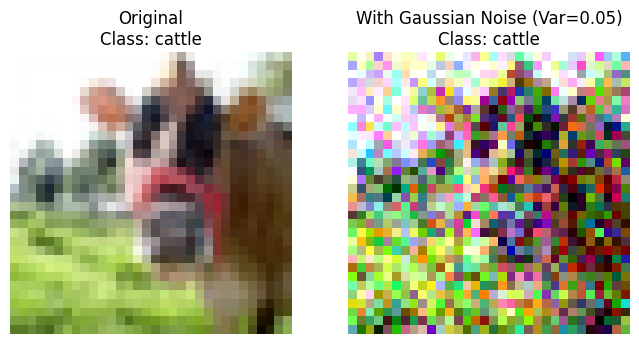

In [4]:
def imshow(img_tensor, title):
    img_tensor=img_tensor.clone() 
    mean=torch.tensor(cifar100_mean).view(3,1,1)
    std=torch.tensor(cifar100_std).view(3,1,1)
    img_tensor=img_tensor*std+mean
    img_tensor=torch.clamp(img_tensor,0,1)
    
    npimg=img_tensor.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.title(title)
    plt.axis('off')

original_image,label=cifar100_original_train[0]
noisy_image,label=cifar100_noisy_train[0]
class_name=cifar100_original_train.classes[label]

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
imshow(original_image,f'Original\nClass: {class_name}')

plt.subplot(1,2,2)
imshow(noisy_image,f'With Gaussian Noise (Var=0.05)\nClass: {class_name}')

plt.show()

Using device:cuda

--- Starting Training on Augmented ORIGINAL Data ---


Epoch 1/20 [Val]: 100%|██████████| 79/79 [00:01<00:00, 51.11it/s]


Epoch 1/20 | Train Loss: 3.8294, Acc: 11.93% | Val Loss: 3.2329, Acc: 21.07% | Time: 26.80s


Epoch 2/20 [Val]: 100%|██████████| 79/79 [00:01<00:00, 52.93it/s]


Epoch 2/20 | Train Loss: 3.1844, Acc: 22.28% | Val Loss: 2.8947, Acc: 27.64% | Time: 26.71s


...

Epoch 18/20 | Train Loss: 2.1076, Acc: 44.74% | Val Loss: 3.3417, Acc: 29.12% | Time: 26.94s


Epoch 19/20 [Val]: 100%|██████████| 79/79 [00:01<00:00, 48.34it/s]


Epoch 19/20 | Train Loss: 2.0897, Acc: 45.03% | Val Loss: 3.2213, Acc: 30.08% | Time: 26.84s


Epoch 20/20 [Val]: 100%|██████████| 79/79 [00:01<00:00, 50.28it/s]


Epoch 20/20 | Train Loss: 2.0732, Acc: 45.53% | Val Loss: 3.1927, Acc: 30.56% | Time: 26.94s

--- Plotting Results ---


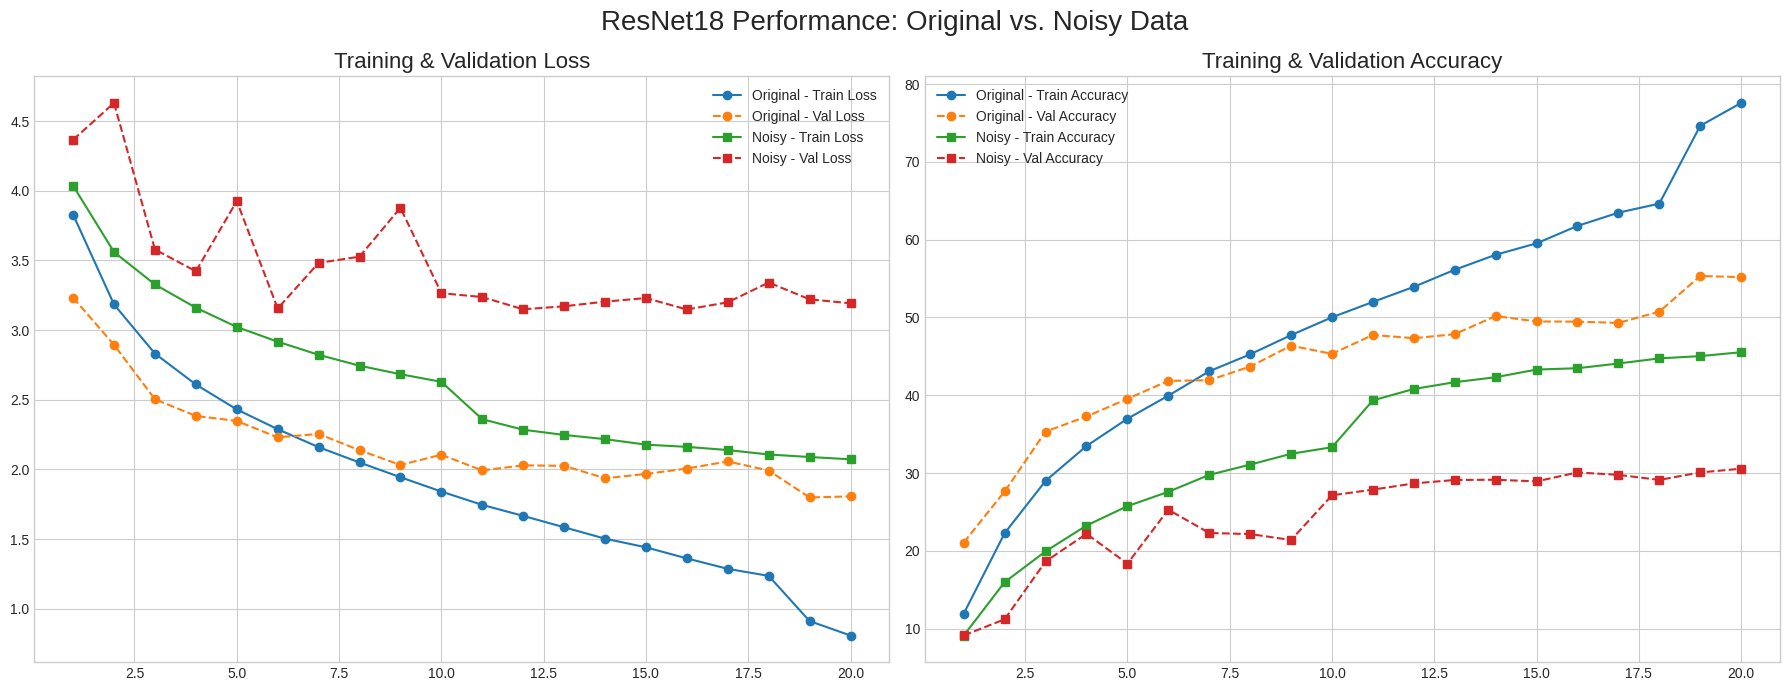

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm 
import matplotlib.pyplot as plt
import numpy as np
import time



EPOCHS=20
BATCH_SIZE=128
LEARNING_RATE=7e-4
NUM_CLASSES=100
DATA_PATH='./data'

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device:{device}")

transform_test_CIFAR=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean,cifar100_std)
])

transform_randaugment=transforms.Compose([
    transforms.RandAugment(num_ops=2,magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean,cifar100_std)
])

transform_noisy_randaugment=transforms.Compose([
    transforms.RandAugment(num_ops=2,magnitude=9),
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.,variance=0.05),
    transforms.Normalize(cifar100_mean,cifar100_std)
])

original_train_set=torchvision.datasets.CIFAR100(root=DATA_PATH,train=True,download=True,transform=transform_randaugment)
noisy_train_set=torchvision.datasets.CIFAR100(root=DATA_PATH,train=True,download=True,transform=transform_noisy_randaugment)
test_set_CIFAR=torchvision.datasets.CIFAR100(root=DATA_PATH,train=False,download=True,transform=transform_test_CIFAR)

train_loader_original=torch.utils.data.DataLoader(original_train_set,batch_size=BATCH_SIZE,shuffle=True,num_workers=2)
train_loader_noisy=torch.utils.data.DataLoader(noisy_train_set,batch_size=BATCH_SIZE,shuffle=True,num_workers=2)
test_loader_CIFAR=torch.utils.data.DataLoader(test_set_CIFAR,batch_size=BATCH_SIZE,shuffle=False,num_workers=2)


def get_model():
    model=torchvision.models.resnet18(weights=None)
    num_features=model.fc.in_features
    model.fc=nn.Linear(num_features,NUM_CLASSES)
    return model.to(device)

def run_training_process(model, train_loader,val_loader):
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(),lr=LEARNING_RATE,weight_decay=1e-4) # Added weight decay
    scheduler=ReduceLROnPlateau(optimizer,mode='min',factor=0.1,patience=3,verbose=True)
    history={'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        start_time=time.time()
        model.train()
        running_loss,correct_train,total_train=0.0,0,0
        for inputs,labels in tqdm(train_loader,desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
            inputs,labels=inputs.to(device),labels.to(device)
            optimizer.zero_grad()
            outputs=model(inputs)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()
            running_loss+=loss.item()
            _,predicted=torch.max(outputs.data,1)
            total_train+=labels.size(0)
            correct_train+=(predicted==labels).sum().item()

        epoch_train_loss=running_loss/len(train_loader)
        epoch_train_acc=100*correct_train/total_train
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        model.eval()
        val_loss,correct_val,total_val=0.0,0,0
        with torch.no_grad():
            for inputs,labels in tqdm(val_loader,desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
                inputs,labels=inputs.to(device),labels.to(device)
                outputs=model(inputs)
                loss=criterion(outputs,labels)
                val_loss+=loss.item()
                _,predicted=torch.max(outputs.data,1)
                total_val+=labels.size(0)
                correct_val+=(predicted==labels).sum().item()

        epoch_val_loss=val_loss/len(val_loader)
        epoch_val_acc=100*correct_val/total_val
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        scheduler.step(epoch_val_loss)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% | Time: {time.time() - start_time:.2f}s")
    return history

def plot_history(h_original,h_noisy,epochs):
    epochs_range=range(1,epochs+1)
    plt.style.use('seaborn-v0_8-whitegrid')
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(18,7))
    ax1.plot(epochs_range,h_original['train_loss'], 'o-',label='Original - Train Loss')
    ax1.plot(epochs_range,h_original['val_loss'], 'o--',label='Original - Val Loss')
    ax1.plot(epochs_range,h_noisy['train_loss'], 's-',label='Noisy - Train Loss')
    ax1.plot(epochs_range,h_noisy['val_loss'],'s--',label='Noisy - Val Loss')
    ax1.set_title('Training & Validation Loss',fontsize=16)
    ax1.legend()
    ax2.plot(epochs_range,h_original['train_acc'], 'o-',label='Original - Train Accuracy')
    ax2.plot(epochs_range,h_original['val_acc'], 'o--',label='Original - Val Accuracy')
    ax2.plot(epochs_range,h_noisy['train_acc'], 's-',label='Noisy - Train Accuracy')
    ax2.plot(epochs_range,h_noisy['val_acc'], 's--',label='Noisy - Val Accuracy')
    ax2.set_title('Training & Validation Accuracy',fontsize=16)
    ax2.legend()
    fig.suptitle('ResNet18 Performance: Original vs. Noisy Data',fontsize=20)
    plt.tight_layout()
    plt.show()

print("\n--- Starting Training on Augmented ORIGINAL Data ---")
model_original=get_model()
history_original=run_training_process(model_original,train_loader_original,test_loader_CIFAR)

print("\n--- Starting Training on Augmented NOISY Data ---")
model_noisy=get_model()
history_noisy=run_training_process(model_noisy,train_loader_noisy,test_loader_CIFAR)

print("\n--- Plotting Results ---")
plot_history(history_original,history_noisy,EPOCHS)

# ViT on Flowers-102

--- Using device: cuda ---
Using transforms for ViT_B_16:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Dataset sizes: Training: 816, Validation: 204

--- Starting Fine-Tuning of vit_b_16 ---


Epoch 1/5 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.37it/s]


Epoch 1/5 | Train Loss: 4.2180, Acc: 14.83% | Val Loss: 3.1940, Acc: 45.10% | Time: 17.71s


Epoch 2/5 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.37it/s]


Epoch 2/5 | Train Loss: 1.9016, Acc: 82.11% | Val Loss: 1.7467, Acc: 75.98% | Time: 17.69s


...

Epoch 3/5 | Train Loss: 0.5874, Acc: 98.77% | Val Loss: 1.0015, Acc: 90.69% | Time: 17.72s


Epoch 4/5 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.33it/s]


Epoch 4/5 | Train Loss: 0.1560, Acc: 100.00% | Val Loss: 0.7023, Acc: 94.12% | Time: 17.70s


Epoch 5/5 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.36it/s]


Epoch 5/5 | Train Loss: 0.0620, Acc: 100.00% | Val Loss: 0.6006, Acc: 95.10% | Time: 17.70s

--- Plotting Fine-Tuning Results ---


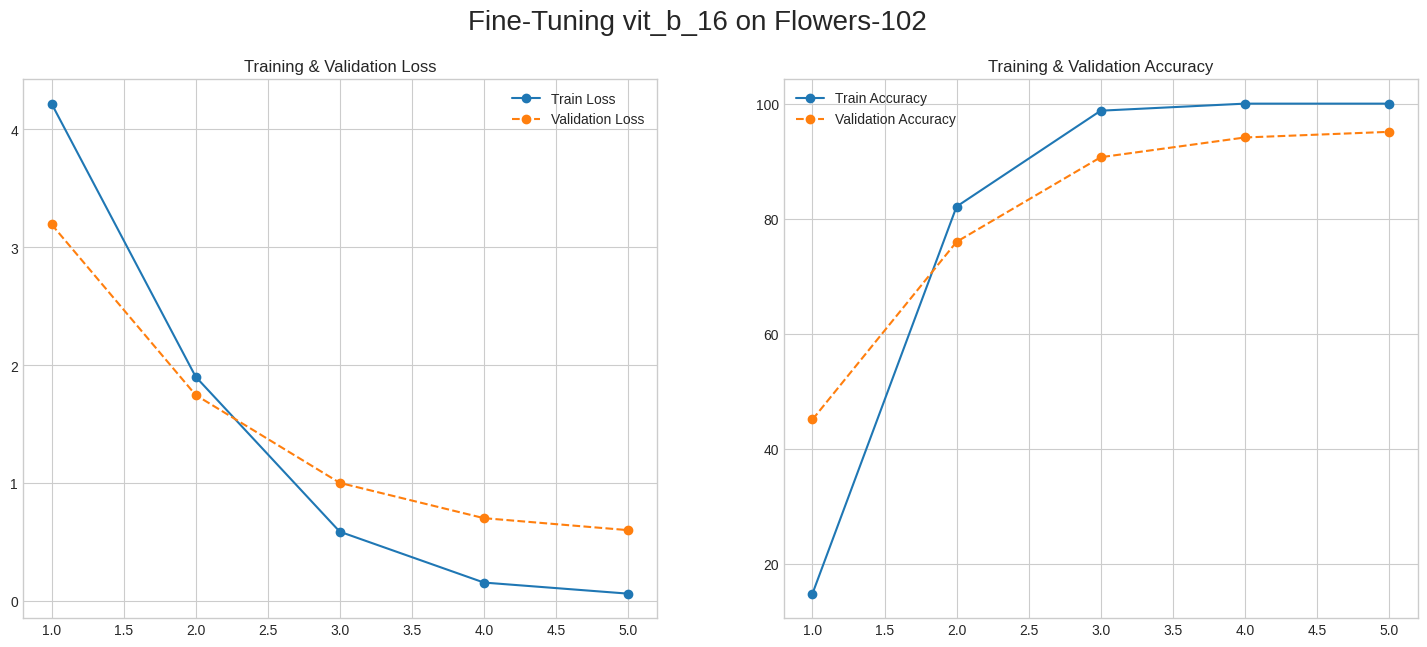

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vit_b_16,ViT_B_16_Weights
from torch.utils.data import DataLoader,random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import time

EPOCHS=5
BATCH_SIZE=32
LEARNING_RATE=1e-4
NUM_CLASSES=102
DATA_PATH='./data'
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Using device: {device} ---")

weights=ViT_B_16_Weights.DEFAULT
model_finetune=vit_b_16(weights=weights)
vit_transforms=weights.transforms()

print("Using transforms for ViT_B_16:")
print(vit_transforms)

full_train_dataset=torchvision.datasets.Flowers102(root=DATA_PATH,
                                                   split='train',download=True,transform=vit_transforms)
test_dataset=torchvision.datasets.Flowers102(root=DATA_PATH,
                                             split='test',download=True,transform=vit_transforms)

train_size=int(0.8*len(full_train_dataset))
val_size=len(full_train_dataset)-train_size
train_dataset,val_dataset=random_split(full_train_dataset,[train_size,val_size])

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2)

print(f"\nDataset sizes: Training: {len(train_dataset)}, Validation: {len(val_dataset)}")

num_features=model_finetune.heads.head.in_features
model_finetune.heads.head=nn.Linear(num_features,NUM_CLASSES)
model_finetune.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model_finetune.parameters(),lr=LEARNING_RATE)
history_finetune={'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

print("\n--- Starting Fine-Tuning of vit_b_16 ---")
for epoch in range(EPOCHS):
    start_time=time.time()
    model_finetune.train()
    running_loss,correct_train,total_train=0.0,0,0
    for inputs,labels in tqdm(train_loader,desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        inputs,labels=inputs.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs=model_finetune(inputs)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
        _, predicted=torch.max(outputs.data,1)
        total_train+=labels.size(0)
        correct_train+=(predicted==labels).sum().item()
    
    epoch_train_loss=running_loss/len(train_loader)
    epoch_train_acc=100*correct_train/total_train
    history_finetune['train_loss'].append(epoch_train_loss)
    history_finetune['train_acc'].append(epoch_train_acc)

    model_finetune.eval()
    val_loss,correct_val,total_val=0.0,0,0
    with torch.no_grad():
        for inputs,labels in tqdm(val_loader,desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            inputs,labels=inputs.to(device),labels.to(device)
            outputs=model_finetune(inputs)
            loss=criterion(outputs, labels)
            val_loss+=loss.item()
            _, predicted=torch.max(outputs.data,1)
            total_val+=labels.size(0)
            correct_val+=(predicted==labels).sum().item()

    epoch_val_loss=val_loss/len(val_loader)
    epoch_val_acc=100*correct_val/total_val
    history_finetune['val_loss'].append(epoch_val_loss)
    history_finetune['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% | Time: {time.time() - start_time:.2f}s")

print("\n--- Plotting Fine-Tuning Results ---")
epochs_range=range(1,EPOCHS+1)
plt.style.use('seaborn-v0_8-whitegrid')
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(18,7))
fig.suptitle('Fine-Tuning vit_b_16 on Flowers-102',fontsize=20)
ax1.plot(epochs_range,history_finetune['train_loss'],'o-',label='Train Loss')
ax1.plot(epochs_range,history_finetune['val_loss'],'o--',label='Validation Loss')
ax1.set_title('Training & Validation Loss');ax1.legend()
ax2.plot(epochs_range,history_finetune['train_acc'],'o-',label='Train Accuracy')
ax2.plot(epochs_range,history_finetune['val_acc'],'o--',label='Validation Accuracy')
ax2.set_title('Training & Validation Accuracy');ax2.legend()
plt.show()

--- Using device: cuda ---

Dataset sizes:
Training:   816 images
Validation: 204 images
Test:       6149 images

--- Loading ViT model with random weights (From Scratch) ---


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/10 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.46it/s]


Epoch 1/10 | Train Loss: 4.5931, Acc: 3.43% | Val Loss: 4.1979, Acc: 4.41% | Time: 17.65s


Epoch 2/10 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.43it/s]


Epoch 2/10 | Train Loss: 3.7577, Acc: 9.80% | Val Loss: 3.9317, Acc: 7.35% | Time: 17.65s


...

Epoch 8/10 | Train Loss: 1.5701, Acc: 58.21% | Val Loss: 3.0951, Acc: 23.53% | Time: 17.66s


Epoch 9/10 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.44it/s]


Epoch 9/10 | Train Loss: 1.1489, Acc: 70.59% | Val Loss: 3.0859, Acc: 26.96% | Time: 17.64s


Epoch 10/10 [Val]: 100%|██████████| 7/7 [00:01<00:00,  4.45it/s]


Epoch 10/10 | Train Loss: 0.8337, Acc: 80.76% | Val Loss: 3.1769, Acc: 25.98% | Time: 17.64s

--- Plotting From-Scratch Training Results ---


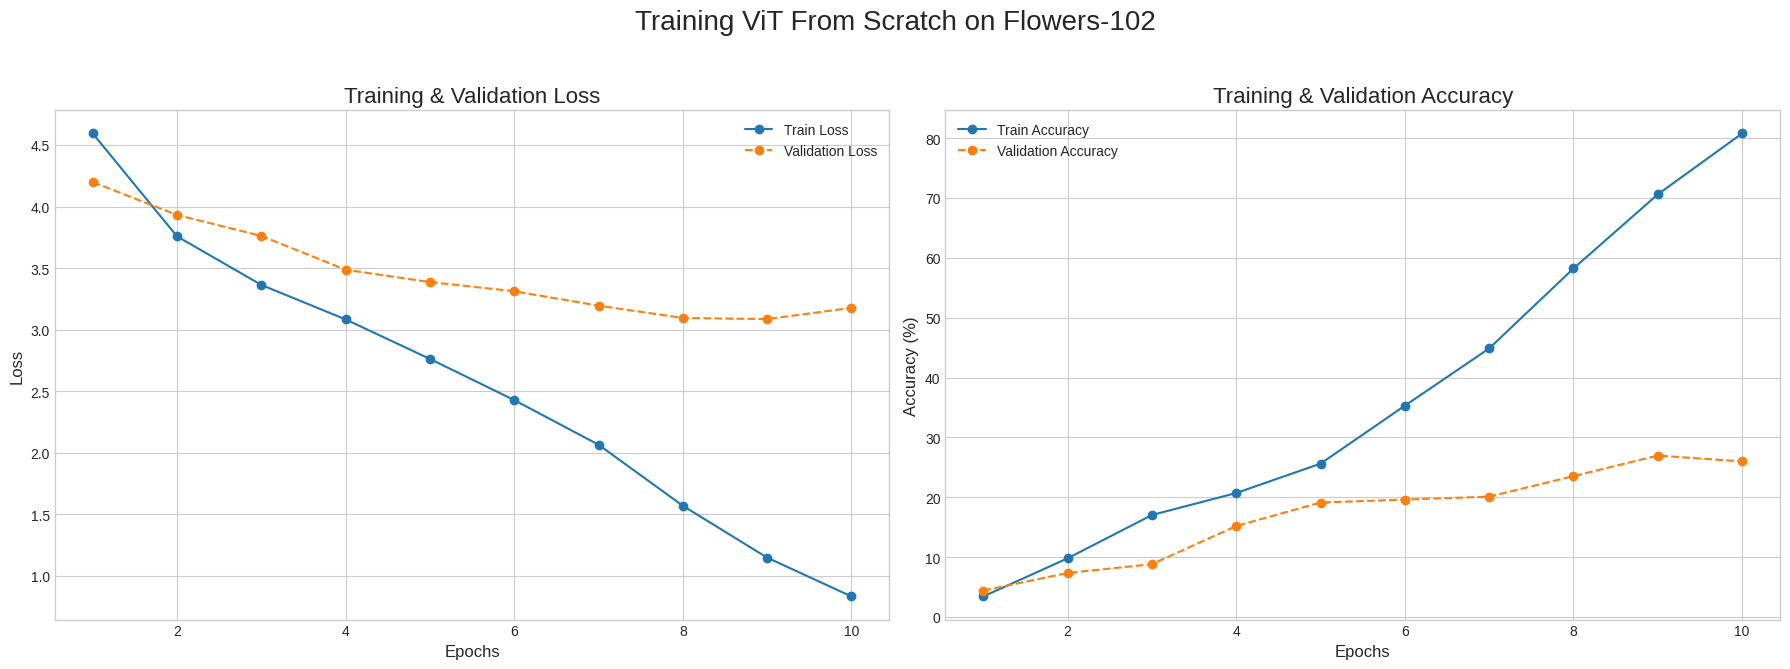

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vit_b_16,ViT_B_16_Weights
from torch.utils.data import DataLoader,random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import time

EPOCHS=10
BATCH_SIZE=32
LEARNING_RATE=7e-5
NUM_CLASSES=102
DATA_PATH='./data'
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Using device: {device} ---")

scratch_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
])

full_train_dataset=torchvision.datasets.Flowers102(root=DATA_PATH,split='train',
                                                   download=True,transform=scratch_transforms)
test_dataset=torchvision.datasets.Flowers102(root=DATA_PATH,split='test',
                                             download=True,transform=scratch_transforms)

train_size=int(0.8*len(full_train_dataset))
val_size=len(full_train_dataset)-train_size
train_dataset,val_dataset=random_split(full_train_dataset,[train_size,val_size])

train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2)

print(f"\nDataset sizes:")
print(f"Training:   {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")
print(f"Test:       {len(test_dataset)} images")

print("\n--- Loading ViT model with random weights (From Scratch) ---")

model_scratch=vit_b_16(pretrained=False)

num_features=model_scratch.heads.head.in_features
model_scratch.heads.head=nn.Linear(num_features,NUM_CLASSES)
model_scratch.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model_scratch.parameters(),lr=LEARNING_RATE)
scheduler=ReduceLROnPlateau(optimizer,mode='min',factor=0.1,patience=2,verbose=True)

history_scratch={'train_loss': [],'val_loss': [],'train_acc': [],'val_acc': []}

for epoch in range(EPOCHS):
    start_time=time.time()
    model_scratch.train()
    running_loss,correct_train,total_train=0.0,0,0
    for inputs,labels in tqdm(train_loader,desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        inputs,labels=inputs.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs=model_scratch(inputs)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
        _,predicted=torch.max(outputs.data,1)
        total_train+=labels.size(0)
        correct_train+=(predicted==labels).sum().item()
    epoch_train_loss=running_loss/len(train_loader)
    epoch_train_acc=100*correct_train/total_train
    history_scratch['train_loss'].append(epoch_train_loss)
    history_scratch['train_acc'].append(epoch_train_acc)
    model_scratch.eval()
    val_loss,correct_val,total_val=0.0,0,0
    with torch.no_grad():
        for inputs,labels in tqdm(val_loader,desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            inputs,labels=inputs.to(device),labels.to(device)
            outputs=model_scratch(inputs)
            loss=criterion(outputs,labels)
            val_loss+=loss.item()
            _,predicted=torch.max(outputs.data,1)
            total_val+=labels.size(0)
            correct_val+=(predicted==labels).sum().item()
    epoch_val_loss=val_loss/len(val_loader)
    epoch_val_acc=100*correct_val/total_val
    history_scratch['val_loss'].append(epoch_val_loss)
    history_scratch['val_acc'].append(epoch_val_acc)
    scheduler.step(epoch_val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% | Time: {time.time() - start_time:.2f}s")

print("\n--- Plotting From-Scratch Training Results ---")
epochs_range=range(1,EPOCHS+1)
plt.style.use('seaborn-v0_8-whitegrid')
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(18,7))
fig.suptitle('Training ViT From Scratch on Flowers-102',fontsize=20)

ax1.plot(epochs_range,history_scratch['train_loss'],'o-',label='Train Loss')
ax1.plot(epochs_range,history_scratch['val_loss'],'o--',label='Validation Loss')
ax1.set_title('Training & Validation Loss',fontsize=16)
ax1.set_xlabel('Epochs',fontsize=12)
ax1.set_ylabel('Loss',fontsize=12)
ax1.legend()

ax2.plot(epochs_range,history_scratch['train_acc'],'o-',label='Train Accuracy')
ax2.plot(epochs_range,history_scratch['val_acc'],'o--',label='Validation Accuracy')
ax2.set_title('Training & Validation Accuracy',fontsize=16)
ax2.set_xlabel('Epochs',fontsize=12)
ax2.set_ylabel('Accuracy (%)',fontsize=12)
ax2.legend()

plt.tight_layout(rect=[0, 0.03,1,0.95])
plt.show()

# حملات متخاصم و دفاع

In [7]:
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import copy
import time


def fgsm_attack(model,images,labels,epsilon=0.1):
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    outputs=model(images)
    loss=nn.CrossEntropyLoss()(outputs,labels)
    model.zero_grad()
    cost=loss
    cost.backward()
    adv_images=images+epsilon*images.grad.sign()
    return adv_images.detach()

def pgd_attack(model,images,labels,epsilon=0.1,alpha=0.02,iters=7):
    images, labels=images.to(device),labels.to(device)
    original_images=images.clone().detach()
    loss=nn.CrossEntropyLoss()
    for i in range(iters):
        images.requires_grad=True
        outputs=model(images)
        model.zero_grad()
        cost=loss(outputs, labels)
        cost.backward()
        adv_images=images+alpha*images.grad.sign()
        eta=torch.clamp(adv_images-original_images,min=-epsilon,max=epsilon)
        images=torch.clamp(original_images+eta,min=-np.inf,max=np.inf).detach()
    return images

def evaluate_all_attacks(model,loader):
    model.eval()
    clean_acc=evaluate_model(model,loader,attack_fn=None,attack_name="Clean")
    fgsm_acc=evaluate_model(model,loader,attack_fn=fgsm_attack,attack_name="FGSM")
    pgd_acc=evaluate_model(model,loader,attack_fn=pgd_attack,attack_name="PGD")
    return {"Clean": clean_acc,"FGSM": fgsm_acc,"PGD": pgd_acc}

def evaluate_model(model,loader,attack_fn=None,attack_name=""):
    model.eval()
    correct,total=0,0
    desc = f"Evaluating ({attack_name})"
    for images,labels in tqdm(loader,desc=desc):
        if attack_fn is not None:
            images=attack_fn(model,images,labels)
        else:
            images=images.to(device)
        labels=labels.to(device)
        with torch.no_grad():
            outputs=model(images)
            _, predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        correct+=(predicted == labels).sum().item()
    return 100 * correct / total

def perform_adversarial_training(original_model,train_loader,epochs=10):
    defended_model=copy.deepcopy(original_model)
    defended_model.train()
    optimizer=torch.optim.Adam(defended_model.parameters(), lr=1e-4)
    criterion=nn.CrossEntropyLoss()
    print(f"\n--- Starting Adversarial Training for {epochs} epochs ---")
    for epoch in range(epochs):
        for images,labels in tqdm(train_loader, desc=f"Adv. Training Epoch {epoch+1}/{epochs}"):
            images,labels=images.to(device),labels.to(device)
            adv_images=pgd_attack(defended_model,images,labels)
            optimizer.zero_grad()
            outputs=defended_model(adv_images)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()
    return defended_model

print("\n--- STEP 1: Evaluating ORIGINAL models (BEFORE defense) ---")
results_before = {}
results_before["Original"]=evaluate_all_attacks(model_original,test_loader_CIFAR)
results_before["Noisy"] =evaluate_all_attacks(model_noisy,test_loader_CIFAR)

print("\n--- STEP 2: Performing Adversarial Training ---")
adv_trained_original=perform_adversarial_training(model_original,train_loader_original)
adv_trained_noisy=perform_adversarial_training(model_noisy,train_loader_original)

print("\n--- STEP 3: Evaluating DEFENDED models (AFTER defense) ---")
results_after = {}
results_after["Original"]=evaluate_all_attacks(adv_trained_original,test_loader_CIFAR)
results_after["Noisy"]=evaluate_all_attacks(adv_trained_noisy,test_loader_CIFAR)

print("\n\n" + "="*75)
print(" " * 17 + "FINAL ResNet Performance Comparison")
print("="*75)
print(f"{'Model Description':<32} | {'Clean Acc':<12} | {'FGSM Acc':<12} | {'PGD Acc':<12}")
print("-" * 75)
print("BEFORE DEFENSE (Original Models)")
print(f"{'  - ResNet (Trained on Original)':<32} | {results_before['Original']['Clean']:<12.2f} | {results_before['Original']['FGSM']:<12.2f} | {results_before['Original']['PGD']:<12.2f}")
print(f"{'  - ResNet (Trained on Noisy)':<32} | {results_before['Noisy']['Clean']:<12.2f} | {results_before['Noisy']['FGSM']:<12.2f} | {results_before['Noisy']['PGD']:<12.2f}")
print("\nAFTER DEFENSE (Adversarially Trained)")
print(f"{'  - ResNet (Trained on Original)':<32} | {results_after['Original']['Clean']:<12.2f} | {results_after['Original']['FGSM']:<12.2f} | {results_after['Original']['PGD']:<12.2f}")
print(f"{'  - ResNet (Trained on Noisy)':<32} | {results_after['Noisy']['Clean']:<12.2f} | {results_after['Noisy']['FGSM']:<12.2f} | {results_after['Noisy']['PGD']:<12.2f}")


--- STEP 1: Evaluating ORIGINAL models (BEFORE defense) ---


Evaluating (PGD): 100%|██████████| 79/79 [00:33<00:00,  2.39it/s]



--- STEP 2: Performing Adversarial Training ---

--- Starting Adversarial Training for 10 epochs ---


Adv. Training Epoch 10/10: 100%|██████████| 391/391 [03:00<00:00,  2.17it/s]



--- Starting Adversarial Training for 10 epochs ---


Adv. Training Epoch 10/10: 100%|██████████| 391/391 [03:00<00:00,  2.17it/s]



--- STEP 3: Evaluating DEFENDED models (AFTER defense) ---


Evaluating (PGD): 100%|██████████| 79/79 [00:33<00:00,  2.39it/s]



                 FINAL ResNet Performance Comparison
Model Description                | Clean Acc    | FGSM Acc     | PGD Acc     
---------------------------------------------------------------------------
BEFORE DEFENSE (Original Models)
  - ResNet (Trained on Original) | 55.18        | 3.97         | 0.54        
  - ResNet (Trained on Noisy)    | 30.56        | 8.32         | 6.24        

AFTER DEFENSE (Adversarially Trained)
  - ResNet (Trained on Original) | 43.24        | 20.06        | 18.16       
  - ResNet (Trained on Noisy)    | 41.81        | 20.53        | 18.78       


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import numpy as np
import copy
import time



def fgsm_attack(model,images,labels,epsilon=0.1):
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    outputs=model(images)
    loss=nn.CrossEntropyLoss()(outputs, labels)
    model.zero_grad()
    cost=loss
    cost.backward()
    adv_images=images+epsilon*images.grad.sign()
    return adv_images.detach()

def pgd_attack(model,images,labels,epsilon=0.1,alpha=0.02,iters=7):
    images, labels=images.to(device),labels.to(device)
    original_images=images.clone().detach()
    loss=nn.CrossEntropyLoss()
    for i in range(iters):
        images.requires_grad = True
        outputs=model(images)
        model.zero_grad()
        cost=loss(outputs, labels)
        cost.backward()
        adv_images=images+alpha*images.grad.sign()
        eta=torch.clamp(adv_images-original_images,min=-epsilon,max=epsilon)
        images=torch.clamp(original_images+eta,min=-np.inf,max=np.inf).detach()
    return images

def evaluate_all_attacks(model,loader):
    model.eval()
    clean_acc=evaluate_model(model,loader,attack_fn=None,attack_name="Clean")
    fgsm_acc=evaluate_model(model,loader,attack_fn=fgsm_attack,attack_name="FGSM")
    pgd_acc=evaluate_model(model,loader,attack_fn=pgd_attack,attack_name="PGD")
    return {"Clean": clean_acc, "FGSM": fgsm_acc, "PGD": pgd_acc}

def evaluate_model(model,loader,attack_fn=None,attack_name=""):
    model.eval()
    correct,total = 0,0
    desc = f"Evaluating ({attack_name})"
    for images,labels in tqdm(loader,desc=desc):
        if attack_fn is not None:
            images=attack_fn(model,images,labels)
        else:
            images=images.to(device)
        labels=labels.to(device)
        with torch.no_grad():
            outputs=model(images)
            _,predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        correct+=(predicted == labels).sum().item()
    return 100 * correct / total

def perform_adversarial_training(original_model,train_loader,epochs=10):
    defended_model=copy.deepcopy(original_model)
    defended_model.train()
    optimizer=torch.optim.Adam(defended_model.parameters(),lr=1e-5) 
    criterion=nn.CrossEntropyLoss()
    print(f"\n--- Starting Adversarial Training for {epochs} epochs ---")
    for epoch in range(epochs):
        for images,labels in tqdm(train_loader,desc=f"Adv. Training Epoch {epoch+1}/{epochs}"):
            images,labels=images.to(device),labels.to(device)
            adv_images=pgd_attack(defended_model,images,labels)
            optimizer.zero_grad()
            outputs=defended_model(adv_images)
            loss=criterion(outputs,labels)
            loss.backward()
            optimizer.step()
    return defended_model


print("\n--- Creating a smaller random subset for evaluation ---")
num_eval_samples=500
full_test_dataset=test_loader.dataset
all_indices=list(range(len(full_test_dataset)))
np.random.shuffle(all_indices)
subset_indices=all_indices[:num_eval_samples]
eval_subset=Subset(full_test_dataset,subset_indices)
eval_loader=DataLoader(eval_subset,batch_size=test_loader.batch_size,shuffle=False)
print(f"Evaluation will run on {len(eval_subset)} random images from the test set.")


print("\n--- STEP 1: Evaluating ORIGINAL ViT models (BEFORE defense) ---")
results_before_vit = {}
results_before_vit["Fine-Tuned"] =evaluate_all_attacks(model_finetune,eval_loader)
results_before_vit["From Scratch"] =evaluate_all_attacks(model_scratch,eval_loader)


print("\n--- STEP 2: Performing Adversarial Training on ViT Models ---")
adv_trained_finetune=perform_adversarial_training(model_finetune,train_loader)
adv_trained_scratch=perform_adversarial_training(model_scratch,train_loader)


print("\n--- STEP 3: Evaluating DEFENDED ViT models (AFTER defense) ---")
results_after_vit = {}
results_after_vit["Fine-Tuned"]=evaluate_all_attacks(adv_trained_finetune,eval_loader)
results_after_vit["From Scratch"]=evaluate_all_attacks(adv_trained_scratch,eval_loader)


print("\n\n" + "="*75)
print(" " * 17 + "FINAL ViT Performance Comparison")
print("="*75)
print(f"{'Model Description':<32} | {'Clean Acc':<12} | {'FGSM Acc':<12} | {'PGD Acc':<12}")
print("-" * 75)
print("BEFORE DEFENSE (Original Models)")
print(f"{'  - ViT (Fine-Tuned)':<32} | {results_before_vit['Fine-Tuned']['Clean']:<12.2f} | {results_before_vit['Fine-Tuned']['FGSM']:<12.2f} | {results_before_vit['Fine-Tuned']['PGD']:<12.2f}")
print(f"{'  - ViT (From Scratch)':<32} | {results_before_vit['From Scratch']['Clean']:<12.2f} | {results_before_vit['From Scratch']['FGSM']:<12.2f} | {results_before_vit['From Scratch']['PGD']:<12.2f}")
print("\nAFTER DEFENSE (Adversarially Trained)")
print(f"{'  - ViT (Fine-Tuned)':<32} | {results_after_vit['Fine-Tuned']['Clean']:<12.2f} | {results_after_vit['Fine-Tuned']['FGSM']:<12.2f} | {results_after_vit['Fine-Tuned']['PGD']:<12.2f}")
print(f"{'  - ViT (From Scratch)':<32} | {results_after_vit['From Scratch']['Clean']:<12.2f} | {results_after_vit['From Scratch']['FGSM']:<12.2f} | {results_after_vit['From Scratch']['PGD']:<12.2f}")


--- Creating a smaller random subset for evaluation ---
Evaluation will run on 500 random images from the test set.

--- STEP 1: Evaluating ORIGINAL ViT models (BEFORE defense) ---


Evaluating (PGD): 100%|██████████| 16/16 [01:09<00:00,  4.36s/it]



--- STEP 2: Performing Adversarial Training on ViT Models ---

--- Starting Adversarial Training for 10 epochs ---


Adv. Training Epoch 10/10: 100%|██████████| 26/26 [02:00<00:00,  4.65s/it]



--- Starting Adversarial Training for 10 epochs ---


Adv. Training Epoch 10/10: 100%|██████████| 26/26 [02:00<00:00,  4.65s/it]



--- STEP 3: Evaluating DEFENDED ViT models (AFTER defense) ---


Evaluating (PGD): 100%|██████████| 16/16 [01:09<00:00,  4.37s/it]



                 FINAL ViT Performance Comparison
Model Description                | Clean Acc    | FGSM Acc     | PGD Acc     
---------------------------------------------------------------------------
BEFORE DEFENSE (Original Models)
  - ViT (Fine-Tuned)             | 86.40        | 4.80         | 0.00        
  - ViT (From Scratch)           | 27.80        | 0.00         | 0.00        

AFTER DEFENSE (Adversarially Trained)
  - ViT (Fine-Tuned)             | 75.80        | 30.20        | 25.40       
  - ViT (From Scratch)           | 29.80        | 5.40         | 4.80        


# بخش اختیاری